# Trench-pull dipole arm — the depth centroid of the shear-stress gradient (Fluidity)

**Position in the project.** This is the Fluidity twin of `trench_pull_mdoodz/model_analysis/centroid_arm.ipynb` — the same construction, run on an independently built code with an independently derived sign chain, which is the point: the analysis is designed so that nothing is carried over except the physics. `fluidity_single_step.ipynb` establishes the trailing-plate force balance here; the manuscript proposes the trench-pull scaling

$$\Delta\mathrm{GPE}^* = (\rho_m - \rho_w)\, g\, w_T\, \frac{h_m}{2} \approx \Delta P_T\, h_{np},$$

whose moment arm is the neutral-plane depth $h_{np} \approx h_m/2$. This notebook measures that arm directly in the stress field, by two independent routes that must agree:

- **Direct** — finite-difference $\tau_{zx}$ in $x$ to form the *equivalent density* $\hat\rho = \tau_{zx,x}/g$, then take its signed depth centroid in each column.
- **Implicit** — $\Delta\mathrm{GPE} / (\Delta\rho\, g\, w)$ gives an effective arm with **no differentiation of the stress field at all**.

**The dipole picture.** Take the first isostatic column $x_I$ ($dV/dx = 0$ seaward of the trench) as reference, and integrate columns to the analysis depth $z_c$, below which stresses are laterally uniform. Relative to $x_I$, a deflected column carries two "charges": a near-surface **mass deficit** $-\Delta\rho\, w$ (the missing rock in the deflected layer), and an equal-and-opposite **equivalent mass** $+\Delta\rho\, w$ distributed at depth, supplied by the shear-stress gradient ($\hat\rho$). The total anomalous mass is zero — the column is *supported*, not compensated — so the column's stress anomaly integrates to a pure dipole moment:

$$\Delta\mathrm{GPE}(x) = \Delta\rho\, g\, w(x) \times \mathrm{arm}(x).$$

**Δ convention in this notebook** (incremental form, defined here per SYMBOLOGY §5): $\Delta f(x) \equiv f(x) - f(x_I)$, a function of $x$ referenced to the first isostatic column. The *deficit* convention $\mathrm{TP}(x) = \bar\sigma_{zz}(x) - \bar\sigma_{zz}(x_I)$ is positive where the column is mass-deficient (the trench), and equals the register's $\Delta\mathrm{GPE}^*$ at $x = x_T$.

## 1. Configuration and load

Extraction is identical to `fluidity_single_step.ipynb` §2–§4: pvtu sampled onto a 200 m regular grid to 75 km depth, off-diagonal sign flip $\sigma_{zx}^{z\text{-down}} = -\sigma_{xy}^{y\text{-up}}$ at extraction, x-mirror to the MDOODZ orientation (subducting plate on the right, seaward = $+x$). This model has a true free surface and no water: $\Delta\rho = \rho_m = 3300$ kg m⁻³, and cells above the deflected surface sample as NaN → set to zero (no material, zero stress). Material standing *above* $z = 0$ at elevated columns is outside the grid and not integrated — the same limitation as every column integral in this repo.

Parameters reported honestly, because the result depends on them: **$x$-smoothing of $\tau_{zx}$ before $d/dx$: 5 km. Mechanical base: 950 °C isotherm, capped at 65 km. Centroid masked where $|\int\Delta\hat\rho\, dz| < 10\%$ of its maximum.**

In [1]:
import sys, glob
from pathlib import Path

import numpy as np
import natsort
import pyvista as pv
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import cumulative_trapezoid

_helpers_dir = str(Path("..").resolve())
if _helpers_dir not in sys.path:
    sys.path.insert(0, _helpers_dir)
import sys, os
_r = os.getcwd()
while not os.path.isdir(os.path.join(_r, 'scripts')) and os.path.dirname(_r) != _r:
    _r = os.path.dirname(_r)
if os.path.join(_r, 'scripts') not in sys.path:
    sys.path.insert(0, os.path.join(_r, 'scripts'))
from cerpa_helpers import (make_field_extractor, mirror_fields_in_x,
                           pick_trench_3step, find_first_isostatic_column)

DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'
MODELS = {'STD': 'STD_RefModel', 'WAL': 'WAL_RefModel'}
MODEL_KEY      = 'WAL'   # 'STD' or 'WAL'
TIMESTEP_INDEX = 10
SECONDS_PER_YEAR = 31_557_600.0

DX        = 200.0        # analysis-grid spacing [m]
Z_MAX     = 75_000.0     # depth extent = analysis depth z_c [m]
Y_SURFACE = 2_900_000.0
MIRROR_X        = True
SUBDUCTING_SIDE = "right" if MIRROR_X else "left"
SEAWARD_SIGN    = +1     if MIRROR_X else -1

G = 9.8
RHO_M, RHO_W = 3300.0, 0.0
DRHO = RHO_M - RHO_W
T_BASE_C       = 950.0   # mechanical base isotherm (report!)
Z_BASE_CAP     = 65e3    # cap on the base depth [m] (report!)
SMOOTH_X_KM    = 5.0     # x-smoothing of tau_zx before d/dx (report!)
MASS_MASK_FRAC = 0.10    # mask centroid where |int Delta rho_hat dz| < frac*max

figures_dir = Path('../../figures'); figures_dir.mkdir(exist_ok=True)

pvtu_files = natsort.natsorted(glob.glob(DATA_ROOT + MODELS[MODEL_KEY] + '/subduction_with_LM*.pvtu'))
ff = pvtu_files[TIMESTEP_INDEX]
print(f"Model {MODEL_KEY!r}: loading timestep {TIMESTEP_INDEX}: {ff.split('/')[-1]}")

Model 'WAL': loading timestep 10: subduction_with_LM_10.pvtu


In [2]:
vtk_data = pv.read(ff)
try:
    t_myr = float(np.asarray(vtk_data["NormalSP::Time"]).ravel()[0]) / SECONDS_PER_YEAR / 1e6
except Exception:
    t_myr = None

vtk_data.point_data["p"]   = vtk_data["NormalSP::Pressure"]
vtk_data.point_data["txx"] = vtk_data["NormalSP::Stress"][:, 0]
vtk_data.point_data["tzz"] = vtk_data["NormalSP::Stress"][:, 4]
vtk_data.point_data["txz"] = -vtk_data["NormalSP::Stress"][:, 1]   # sign flip at extraction
vtk_data.point_data["T"]   = vtk_data["NormalSP::Temperature"]
vtk_data.point_data["fs"]  = vtk_data["NormalSP::FreeSurface"]
vel = vtk_data["NormalSP::Velocity"] / 3.17098e-10   # m/s -> m/yr
vtk_data.point_data["vx"] = vel[:, 0]
vtk_data.point_data["vy"] = vel[:, 1]

x_min, x_max, _, _, _, _ = vtk_data.bounds
nx = int((x_max - x_min) / DX)
nz = int(Z_MAX / DX)
x = x_min + (np.arange(nx) + 0.5) * DX
z = (np.arange(nz) + 0.5) * DX               # depth, positive down
X, Z = np.meshgrid(x, z, indexing="xy")
grid = pv.StructuredGrid(X.T, (Y_SURFACE - Z).T, np.zeros_like(X.T))
interp = grid.sample(vtk_data)
nx_pv, nz_pv, _ = interp.dimensions
valid = interp["vtkValidPointMask"].reshape((nx_pv, nz_pv), order="F").astype(bool)
get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)
p, txx, tzz, txz = get_field("p"), get_field("txx"), get_field("tzz"), get_field("txz")
T, fs = get_field("T"), get_field("fs")
vx, vz = get_field("vx"), -get_field("vy")
p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
print("(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)")

# full-tensor components, z down; NaN (above the free surface) -> zero stress
sigma_zz = np.nan_to_num(-p + tzz)
sigma_xx = np.nan_to_num(-p + txx)
tau_zx   = np.nan_to_num(txz)

fs_top = fs[0, :].copy()
bad = np.isnan(fs_top)          # columns whose surface dips below the first grid row
for j in np.where(bad)[0]:
    k = np.where(np.isfinite(fs[:, j]))[0]
    fs_top[j] = fs[k[0], j] if len(k) else 0.0
print(f"grid ({nz}, {nx});  fs range {np.nanmin(fs_top):.0f} .. {np.nanmax(fs_top):.0f} m"
      + (f";  t = {t_myr:.1f} Myr" if t_myr is not None else ""))

ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


...

ERROR:root:Piece cell data array vtkGhostLevels not found


ERROR:root:Piece cell data array vtkGhostLevels not found


/opt/anaconda3/envs/pyvista-env/lib/python3.12/site-packages/pyvista/core/utilities/fileio.py:308: UserWarning: The VTK reader `vtkXMLPUnstructuredGridReader` in pyvista reader `XMLPUnstructuredGridReader('/Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/subduction_with_LM_10.pvtu')` raised an error while reading the file.
	"Piece cell data array vtkGhostLevels not found"
  warnings.warn(


(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)


grid (375, 39999);  fs range -3254 .. 1201 m;  t = 20.0 Myr


## 2. Key columns

The trench $x_T$ comes from the repo's 3-step picker (surface-pressure minimum, refined by the velocity sign change). The first isostatic column $x_I$ uses the register's definition — the first sign change of $dV/dx$ seaward of the trench, skipping the first 10 km — with the helpers' free-surface-recovery picker printed alongside as a cross-check. The forebulge $x_b$ is the free-surface maximum between them, and $x_m$ (maximum bending moment) is the zero crossing of $V$. Deflection $w$ is positive downward and zero at $x_I$.

In [3]:
x_trench, info = pick_trench_3step(x, z, p, vx, vx_depth_m=5000, Wp1_km=1000,
                                   Wv_km=800, Wp3_km=800, smooth_km=40,
                                   subducting_side=SUBDUCTING_SIDE)
ti = int(np.argmin(np.abs(x - x_trench)))

V = np.trapz(tau_zx, z, axis=0)                    # int tau_zx^extracted dz
dVdx = np.gradient(gaussian_filter1d(V, int(10e3 / DX)), x)

i = ti + int(10e3 / DX)                            # skip 10 km
s0 = np.sign(dVdx[i])
while np.sign(dVdx[i]) == s0 and x[i] < x[ti] + 400e3:
    i += 1
iI = i                                             # first isostatic column
ib = ti + int(np.argmax(fs_top[ti:iI + int(200e3 / DX)]))          # forebulge
zc_V = np.where(np.diff(np.sign(V[ti:iI])) != 0)[0]
im = ti + int(zc_V[0]) if len(zc_V) else (ti + iI) // 2            # max bending moment

iI_fs, _ = find_first_isostatic_column(x, fs_top, x_trench, ti, DX,
                                       seaward_sign=SEAWARD_SIGN)
print(f"x_T = {x[ti]/1e3:.0f} km, x_m = {x[im]/1e3:.0f}, x_b = {x[ib]/1e3:.0f}, "
      f"x_I = {x[iI]/1e3:.0f} km  (L_TI = {(x[iI]-x[ti])/1e3:.0f} km)")
print(f"cross-check: fs-recovery picker puts x_I at {x[iI_fs]/1e3:.0f} km")

w = fs_top[iI] - fs_top                            # deflection, + down, 0 at x_I
w_T = w[ti]
print(f"w_T = {w_T:.0f} m")

x_T = 4440 km, x_m = 4459, x_b = 4576, x_I = 4520 km  (L_TI = 79 km)
cross-check: fs-recovery picker puts x_I at 4518 km
w_T = 1717 m


## 3. Step 0 — pin the sign of $\hat\rho$ on the data

The sign chain from the raw Fluidity stress through the extraction flip and the x-mirror to the register's $\tau_{zx}$ is a known trap — SYMBOLOGY §7.5 records that this repo's extracted $\tau_{zx}$ *matches* the register's sense while MDOODZ's is its negative. Rather than trust that bookkeeping, the sign of $\hat\rho$ relative to the extracted field is decided **empirically** by the column-pair identity

$$\frac{d\,\Delta\sigma_{zz}}{dz} = -g\,\Delta\hat\rho(z)$$

(true density cancels between same-structure trailing-plate columns, leaving only the equivalent density). The check runs in **cumulative** form — $\Delta\sigma_{zz}(z)$ against a two-charge prediction: a topographic step (ramping to $\Delta\rho\, g\, w_T$ over the deflected surface layer) plus the cumulative shear term, tried with both signs; the data picks the winner by rms. If the winning sign here comes out *opposite* to the MDOODZ notebook, that is §7.5 confirmed on the data, not an error.

In [4]:
D = sigma_zz - sigma_zz[:, [iI]]                   # Delta sigma_zz(z), ref x_I
tau_s = gaussian_filter1d(tau_zx, SMOOTH_X_KM * 1e3 / DX, axis=1)
dtau_dx = np.gradient(tau_s, x, axis=1)
dTdx_T = dtau_dx[:, ti] - dtau_dx[:, iI]
Q_T = cumulative_trapezoid(dTdx_T, z, initial=0.0)
# two-charge prediction: topographic surface-mass step + shear support at depth
topo_step = DRHO * G * np.clip(z - (-fs_top[iI]), 0.0, w_T)
zwin = (z > 2e3) & (z < 60e3)
best = None
for s in (+1.0, -1.0):
    pred = topo_step + s * Q_T
    r = np.corrcoef(D[zwin, ti], pred[zwin])[0, 1]
    rms = np.sqrt(np.mean((D[zwin, ti] - pred[zwin]) ** 2))
    print(f"  s = {s:+.0f}: corr = {r:+.3f}, closure rms = {rms/1e6:.2f} MPa")
    if best is None or rms < best[2]:
        best = (s, r, rms)
SGN, rp, rms0 = best
rho_hat = -SGN * dtau_dx / G      # D' = -g*(m_topo + Delta rho_hat) => rho_hat sign
resid_scale = np.sqrt(np.mean(D[zwin, ti] ** 2))
print(f"step 0 (two-charge): corr(D, pred) = {rp:+.3f}, closure rms = "
      f"{rms0/1e6:.2f} MPa vs field scale {resid_scale/1e6:.2f} MPa; "
      f"rho_hat = {'-' if SGN>0 else '+'}(1/g) d tau_zx^extracted/dx")

  s = +1: corr = -0.926, closure rms = 67.61 MPa
  s = -1: corr = +0.926, closure rms = 8.19 MPa
step 0 (two-charge): corr(D, pred) = +0.926, closure rms = 8.19 MPa vs field scale 34.37 MPa; rho_hat = +(1/g) d tau_zx^extracted/dx


## 4. Direct route — signed centroid of $\Delta\hat\rho$

For each column from the trench to beyond $x_I$: integrate $\Delta\hat\rho$ (referenced to $x_I$) from the local free surface down to the mechanical base, and take the signed depth centroid $\int z\,\Delta\hat\rho\,dz \,/\, \int\Delta\hat\rho\,dz$. The centroid is meaningless where the net equivalent mass is small, so columns with $|\int\Delta\hat\rho\,dz|$ below 10 % of the maximum are masked, and the count is reported. The 950 °C isotherm depth at $x_I$ doubles as the mechanical-thickness estimate $h_m$ for the $\mathrm{arm} \approx h_m/2$ comparison.

**Mass check** — the arbiter for the whole construction: the integrated equivalent mass must equal the surface deficit, $\int\Delta\hat\rho\,dz = \Delta\rho\, w$. A median ratio of $+1$ says the sign pin and the amplitude are both right.

In [5]:
z_surf = -fs_top                                   # free-surface depth (z down)
z_base = np.array([z[np.argmax(T[:, j] > (T_BASE_C + 273.15))] for j in range(len(x))])
z_base = np.minimum(z_base, Z_BASE_CAP)
h_m = z_base[iI]                                   # mechanical thickness at x_I
print(f"h_m ({T_BASE_C:.0f} C isotherm at x_I) = {h_m/1e3:.1f} km  ->  h_m/2 = {h_m/2e3:.1f} km")

sea = slice(ti, min(iI + (iI - ti), len(x)))       # trench -> beyond x_I
xs = x[sea]
cent_d = np.full(len(xs), np.nan)
mass_d = np.full(len(xs), np.nan)
rr = rho_hat - rho_hat[:, [iI]]                    # Delta rho_hat, ref x_I
for k, j in enumerate(range(sea.start, sea.stop)):
    zm = (z >= z_surf[j]) & (z <= z_base[j])
    m = np.trapz(rr[zm, j], z[zm])
    zc_ = np.trapz(z[zm] * rr[zm, j], z[zm])
    mass_d[k] = m
    cent_d[k] = zc_ / m if m != 0 else np.nan
mask = abs(mass_d) < MASS_MASK_FRAC * np.nanmax(abs(mass_d))
cent_d[mask] = np.nan
print(f"direct: masked {mask.sum()}/{len(xs)} columns (|int rho_hat| < {MASS_MASK_FRAC:.0%} of max)")
# mass check: int(Delta rho_hat) dz  vs  Delta rho * w
mass_pred = DRHO * w[sea]
mgood = ~np.isnan(mass_d) & (abs(mass_pred) > 0.2 * np.nanmax(abs(mass_pred)))
mass_ratio = np.nanmedian(mass_d[mgood] / mass_pred[mgood])
print(f"mass check: median  int(Delta rho_hat)dz / (Delta rho * w) = {mass_ratio:+.2f}  (want ~ +1)")

h_m (950 C isotherm at x_I) = 58.1 km  ->  h_m/2 = 29.1 km
direct: masked 141/792 columns (|int rho_hat| < 10% of max)
mass check: median  int(Delta rho_hat)dz / (Delta rho * w) = +1.00  (want ~ +1)


## 5. Implicit route, validation, and the regression arm

The implicit arm needs no differentiation: $\mathrm{arm}(x) = \mathrm{TP}(x)/(\Delta\rho\, g\, w) - w/2$, where the $w/2$ subtracts the surface charge's own half-depth moment so both routes measure the depth of the *shear-supported* charge. Restricted to columns with $|w| > 100$ m.

Two validations ride along: $\mathrm{corr}(-\Delta N_D, \Delta\mathrm{GPE})$ over the window (the trailing-plate balance says these track identically), and a regression of $\mathrm{TP}$ against $\Delta\rho\, g\, w$ over all windowed columns — the slope **is** the arm, forebulge points included (there $w$ and $\mathrm{TP}$ both change sign, so they pull the line through the origin rather than polluting it).

In [6]:
TP = np.trapz(D, z, axis=0)                        # = register Delta GPE* at x_T
arm_i = np.full(len(x), np.nan)
ok = abs(w) > 100.0
arm_i[ok] = TP[ok] / (DRHO * G * w[ok]) - w[ok] / 2.0   # subtract surface half-moment
# N_D tracking check
N_D = np.trapz(sigma_xx - sigma_zz, z, axis=0)
dN = N_D - N_D[iI]
r_track = np.corrcoef(-dN[sea], TP[sea])[0, 1]  # TP deficit-positive; dN opposite
print(f"validation: corr(-Delta N_D, Delta GPE) over the window = {r_track:+.3f} (identity: +1)")

# key-column numbers
for name, j in (("x_T", ti), ("x_m", im), ("x_b", ib)):
    k = j - sea.start
    ci = arm_i[j]
    cd = cent_d[k] if 0 <= k < len(cent_d) else np.nan
    print(f"{name}: w = {w[j]:+7.0f} m  TP = {TP[j]*1e-12:+.2f} TN/m  "
          f"arm(direct) = {cd/1e3 if np.isfinite(cd) else float('nan'):5.1f} km  "
          f"arm(implicit) = {ci/1e3 if np.isfinite(ci) else float('nan'):5.1f} km")

# regression: TP vs Drho*g*w over the window (slope = arm)
fitmask = ok.copy(); fitmask[:sea.start] = False; fitmask[sea.stop:] = False
A = np.vstack([DRHO * G * w[fitmask], np.ones(fitmask.sum())]).T
arm_fit, off = np.linalg.lstsq(A, TP[fitmask], rcond=None)[0]
print(f"regression arm (TP vs Drho g w slope) = {arm_fit/1e3:.1f} km "
      f"(offset {off*1e-12:+.2f} TN/m);  arm/h_m = {arm_fit/h_m:.2f}")

validation: corr(-Delta N_D, Delta GPE) over the window = +0.999 (identity: +1)
x_T: w =   +1717 m  TP = +1.82 TN/m  arm(direct) =  28.9 km  arm(implicit) =  31.9 km
x_m: w =   +1414 m  TP = +1.64 TN/m  arm(direct) =  30.3 km  arm(implicit) =  35.3 km
x_b: w =    -305 m  TP = -0.23 TN/m  arm(direct) =  22.7 km  arm(implicit) =  23.4 km
regression arm (TP vs Drho g w slope) = 32.4 km (offset +0.12 TN/m);  arm/h_m = 0.56


## 6. Figure

(a) $\Delta\hat\rho$ profiles at the three key columns with their signed centroids; (b) the centroid track by both routes, against distance from the trench; (c) the deficit force $\Delta\mathrm{GPE}$, the normal-stress-difference resultant $\Delta N_D$, and the deflection $w$; (d) the dipole line — $\mathrm{TP}$ against $\Delta\rho\, g\, w$, whose slope is the arm.

figure: ../../figures/centroid_arm_WAL_f10.png


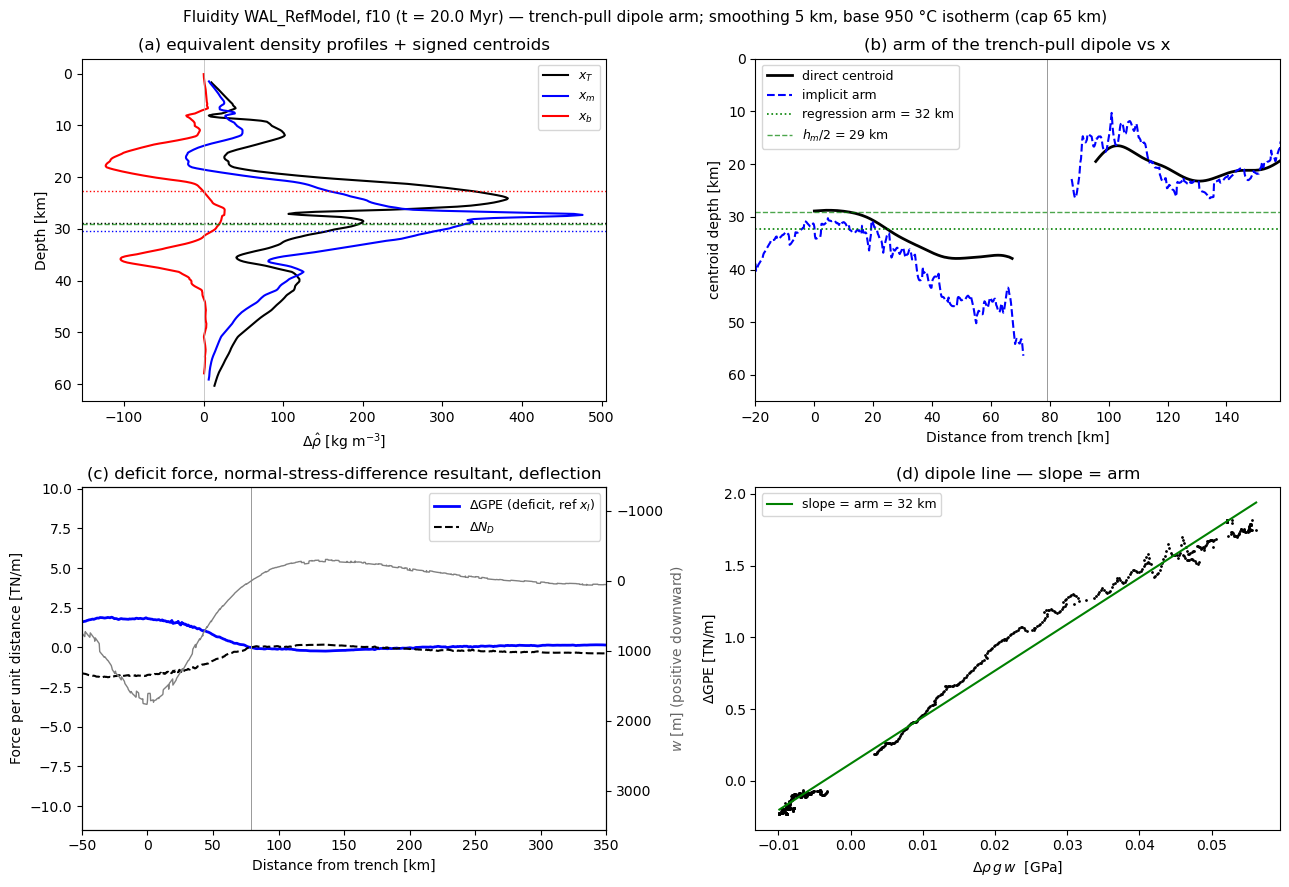

In [7]:
xkm = (x - x[ti]) / 1e3
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# (a) rho_hat profiles at key columns
for name, j, c in (("$x_T$", ti, "k"), ("$x_m$", im, "b"), ("$x_b$", ib, "r")):
    zm = (z >= z_surf[j]) & (z <= z_base[j])
    axes[0, 0].plot(rr[zm, j], z[zm] / 1e3, c, lw=1.5, label=name)
    k = j - sea.start
    if 0 <= k < len(cent_d) and np.isfinite(cent_d[k]):
        axes[0, 0].axhline(cent_d[k] / 1e3, color=c, ls=":", lw=1)
axes[0, 0].axhline(h_m / 2e3, color="g", ls="--", lw=1, alpha=0.7)
axes[0, 0].axvline(0, color="0.7", lw=0.5)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel(r"$\Delta\hat\rho$ [kg m$^{-3}$]")
axes[0, 0].set_ylabel("Depth [km]")
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_title("(a) equivalent density profiles + signed centroids")

# (b) centroid track, both routes
axes[0, 1].plot(xkm[sea], cent_d / 1e3, "k-", lw=2, label="direct centroid")
axes[0, 1].plot(xkm, arm_i / 1e3, "b--", lw=1.5, label="implicit arm")
axes[0, 1].axhline(arm_fit / 1e3, color="g", ls=":", lw=1.2,
                   label=f"regression arm = {arm_fit/1e3:.0f} km")
axes[0, 1].axhline(h_m / 2e3, color="g", ls="--", lw=1, alpha=0.7,
                   label=f"$h_m/2$ = {h_m/2e3:.0f} km")
axes[0, 1].axvline((x[iI] - x[ti]) / 1e3, color="0.6", lw=0.7)
axes[0, 1].set_xlim(-20, xkm[sea][-1])
axes[0, 1].set_ylim(65, 0)
axes[0, 1].set_xlabel("Distance from trench [km]")
axes[0, 1].set_ylabel("centroid depth [km]")
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_title("(b) arm of the trench-pull dipole vs x")

# (c) TP, dN_D, w
ax = axes[1, 0]
ax.plot(xkm, TP * 1e-12, "b-", lw=2, label=r"$\Delta$GPE (deficit, ref $x_I$)")
ax.plot(xkm, dN * 1e-12, "k--", lw=1.5, label=r"$\Delta N_D$")
ax2 = ax.twinx()
ax2.plot(xkm, w, color="0.5", lw=1, label="$w$")
ax2.set_ylabel("$w$ [m] (positive downward)", color="0.4")
ax2.invert_yaxis()
ax.axvline((x[iI] - x[ti]) / 1e3, color="0.6", lw=0.7)
ax.set_xlim(-50, 350)
ax.set_xlabel("Distance from trench [km]")
ax.set_ylabel("Force per unit distance [TN/m]")
ax.legend(fontsize=9, loc="upper right")
ax.set_title("(c) deficit force, normal-stress-difference resultant, deflection")

# (d) TP vs Drho g w correlation
axes[1, 1].plot(DRHO * G * w[fitmask] * 1e-9, TP[fitmask] * 1e-12, "k.", ms=2)
ww = np.linspace(np.nanmin(DRHO * G * w[fitmask]), np.nanmax(DRHO * G * w[fitmask]), 2)
axes[1, 1].plot(ww * 1e-9, (arm_fit * ww + off) * 1e-12, "g-", lw=1.5,
                label=f"slope = arm = {arm_fit/1e3:.0f} km")
axes[1, 1].set_xlabel(r"$\Delta\rho\, g\, w$  [GPa]")
axes[1, 1].set_ylabel(r"$\Delta$GPE [TN/m]")
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_title("(d) dipole line — slope = arm")

tstr = f" (t = {t_myr:.1f} Myr)" if t_myr is not None else ""
fig.suptitle(f"Fluidity {MODELS[MODEL_KEY]}, f{TIMESTEP_INDEX}{tstr} — "
             f"trench-pull dipole arm; smoothing {SMOOTH_X_KM:.0f} km, "
             f"base {T_BASE_C:.0f} °C isotherm (cap {Z_BASE_CAP/1e3:.0f} km)", fontsize=11)
fig.tight_layout()
out = figures_dir / f"centroid_arm_{MODEL_KEY}_f{TIMESTEP_INDEX}.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
print("figure:", out)

**Interpretation**

- Both routes put the arm at **~29–35 km depth** across the flexural window; the regression slope agrees at **~32 km**. Against the mechanical thickness measured from the same snapshot ($h_m \approx 58$ km, 950 °C isotherm at $x_I$), that is $\mathrm{arm} \approx 0.56\, h_m$ — the mid-plate arm of the manuscript scaling, recovered from the stress field of a second, independently built code. Switching `MODEL_KEY` to `'STD'` gives the same ratio (regression arm ~35 km, $h_m \approx 62$ km, $\mathrm{arm}/h_m = 0.56$).
- **The sign pin came out opposite to MDOODZ** — here $\hat\rho = +(1/g)\,\partial\tau_{zx}^{\mathrm{extracted}}/\partial x$, there the minus sign — which is exactly what SYMBOLOGY §7.5 records about the two repos' extraction chains. Step 0 resolving that *from the data alone* (winner by rms 8 vs 68 MPa) is the strongest evidence that the construction is measuring physics, not bookkeeping.
- Internal closure matches the MDOODZ result: mass check $+1.00$, $\mathrm{corr}(-\Delta N_D, \Delta\mathrm{GPE}) = +0.999$, and the forebulge points in panel (d) fall on the same line through the origin as the trench-side points — one arm describes the whole flexural signal.
- Both routes and both Fluidity models land slightly **below** the mid-plane ($0.56\, h_m$ rather than $0.50$; MDOODZ gave $0.50$). The offset is consistent across routes, so it is a property of this model's stress distribution (or of the base/smoothing choices) rather than noise — worth watching in the time series before reading anything into it.
- Honesty box: 5 km $x$-smoothing of $\tau_{zx}$ before differencing; mechanical base at the 950 °C isotherm capped at 65 km (the isotherm is operative at $x_I$; the cap binds near the trench); centroid masked below 10 % of peak net mass; material above $z=0$ at elevated columns is not integrated. The sign of $\hat\rho$ is **pinned empirically per run** by step 0 — the mass check is the arbiter; never carry a sign chain between runs or repos.

**Next**: run the arm through the STD and WAL time series alongside the MDOODZ MD7_R0 series, and compare against $h_{np}$ tracked independently from stress profiles.